# Exploring EW4 data - GPM IMERG
This notebook explore the GPM IMERG dataset, including loading in PyEarthTools.

This dataset is a subset of the [NASA Integrated Multi-satellite Retrieval (IMERG)](https://gpm.nasa.gov/data/imerg) data for Global Precipitation Measurement (GPM). This subset has the following extents:
- Temporal Extent: April to September 2025
- Spatial Extent
  - Latitude 0N to 20N
  - Longitude 27W to 20E


### Import libraries

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pathlib
import datetime
import functools
import math

In [4]:
import numpy

In [5]:
import xarray

In [6]:
import matplotlib
import cartopy.crs

In [7]:
import site_archive_jasmin

ROOT_DIRECTORIES: {'ERA5lowres': '/gws/nopw/j04/mohc_shared/dscop/weatherbench/5.625deg/', 'MOGLOBAL': '/gws/nopw/j04/mohc_shared//dscop/mo_pet_site_archive/mo_global/', 'MOUKV': '/gws/nopw/j04/mohc_shared//dscop/mo_pet_site_archive/mo_ukv/', 'Himawari': '/gws/ssde/j25a/mmh_storage/theme3/rv74_himawari', 'HimawariChannels': '/gws/ssde/j25a/mmh_storage/theme3/ra22_himawari', 'Rainfields3': '/gws/ssde/j25a/mmh_storage/theme3/rq0Radar', 'ew4_imerg_precip': '/gws/nopw/j04/ew4energy/imerg_2025_summer', 'ew4_merra2_meteo': '/gws/nopw/j04/ew4energy/West_Africa_Merra-2_2015-2025_meteo', 'ew4_merra2_aero': '/gws/nopw/j04/ew4energy/West_Africa_Merra-2_2015-2025_aerosols/3d', 'ew4_mtg_li': '/gws/nopw/j04/ew4energy/MTG_LI/', 'ew4_era5': '/gws/nopw/j04/ew4energy/ERA5/tutorial_202606'}


In [8]:
import pyearthtools

In [9]:
import pyearthtools.data as petdata
import pyearthtools.pipeline as petpipe

In [10]:
from pyearthtools.data import Petdt, TimeDelta
from pyearthtools.data.exceptions import DataNotFoundError
from pyearthtools.data.indexes import ArchiveIndex, decorators
from pyearthtools.data.transforms import Transform, TransformCollection
from pyearthtools.data.archive import register_archive


In [11]:
from site_archive_jasmin.utilities import (
    cached_exists,
    cached_iterdir,
)  # Could these be moved into a generic module?


## Explore the data in the dataset
Lets start by looking at a sample data file, before demonstrating loading the data in pyearthtools. From this we can learn the following things about the dataset
* The pattern of filenames for accessing the data
* The spatial and tempoeral extents of the data
* The variables present in the data
* Any potential problems with its usage, which can be fixed in the PyEarthTools data accessor class
* Plot some data so we can check that PyEarthTools loads it correctly.

We'll be using the IMERG data in the EW4 Group Workspace. It is also available through other sources:
* [NASA](https://gpm.nasa.gov/data/imerg)
* [AWS Open Data](https://registry.opendata.aws/nasa-gpm3imergm/)
* [CEDA Archive - available on JASMIN](https://catalogue.ceda.ac.uk/uuid/47c32530265d4d6e8fdb6c08b2330371/)


In [100]:
ew4_gws_dir = pathlib.Path('/gws/nopw/j04/ew4energy/')
imerg_ew4_dir = ew4_gws_dir / 'imerg_2025_summer'
ew4_gws_user_dir = ew4_gws_dir / 'user' / 'shaddad'
ew4_user_cache_dir = ew4_gws_user_dir / 'cache'
ew4_imerg_cache_dir = ew4_user_cache_dir / 'imerg'
imerg_norm_dir = ew4_imerg_cache_dir / 'norms'
ew4_imerg_ml_prepped_dir = ew4_imerg_cache_dir / 'ml_prepped'

In [16]:
def get_imerg_path(start_dt, time_delta, fname_template, data_dir):
    """
    Convenience function for constructing paths.
    """
    day_minutes = start_dt.hour * 60 + start_dt.minute
    date_str = '{dt.year:04d}{dt.month:02d}{dt.day:02d}'.format(dt=start_dt)
    time_template = '{dt.hour:02d}{dt.minute:02d}{dt.second:02d}'
    start_time = time_template.format(dt=start_dt)
    end_time = time_template.format(dt=start_dt+time_delta-datetime.timedelta(seconds=1))
    imerg_path = data_dir / fname_template.format(date_str=date_str,
                                              start_time=start_time,
                                              end_time=end_time,
                                                  day_minutes=day_minutes,
                                             )
    return imerg_path


In [17]:
imerg_fname_template = '3B-HHR-E.MS.MRG.3IMERG.{date_str}-S{start_time}-E{end_time}.{day_minutes:04d}.V07B.HDF5.SUB.nc4'

In [18]:
start_dt = datetime.datetime(2025,5,1,0,0)
end_dt = datetime.datetime(2025,6,1,0,0)
time_delta=datetime.timedelta(minutes=30)

In [19]:
num_files = int((end_dt - start_dt) / time_delta)

In a month we have 2 files per hour, 24 hours per day for 31 days, 

In [20]:
num_files

1488

In [21]:
imerg_filelist = [
    get_imerg_path(start_dt + (time_delta * time_ix),
                   time_delta,
                   imerg_fname_template,
                   imerg_ew4_dir
                  )
    for time_ix in range(num_files) ]


In [22]:
imerg_filelist

[PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S000000-E002959.0000.V07B.HDF5.SUB.nc4'),
 PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S003000-E005959.0030.V07B.HDF5.SUB.nc4'),
 PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S010000-E012959.0060.V07B.HDF5.SUB.nc4'),
 PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S013000-E015959.0090.V07B.HDF5.SUB.nc4'),
 PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S020000-E022959.0120.V07B.HDF5.SUB.nc4'),
 PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S023000-E025959.0150.V07B.HDF5.SUB.nc4'),
 PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S030000-E032959.0180.V07B.HDF5.SUB.nc4'),
 PosixPath('/gws/nopw/j04/ew4energy/imerg_2025_summer/3B-HHR-E.MS.MRG.3IMERG.20250501-S033000-E035959.02

In [23]:
ew4_imerge_sample_ds = xarray.open_mfdataset(imerg_filelist)

We have now loaded a month worth of precip data into a single xarray dataset.

In [24]:
ew4_imerge_sample_ds

<xarray.Dataset> Size: 564MB
Dimensions:        (time: 1488, lon: 469, lat: 202)
Coordinates:
  * time           (time) datetime64[ns] 12kB 2025-05-01 ... 2025-05-31T23:30:00
  * lon            (lon) float32 2kB -27.05 -26.95 -26.85 ... 19.55 19.65 19.75
  * lat            (lat) float32 808B 0.05 0.15 0.25 0.35 ... 19.95 20.05 20.15
Data variables:
    precipitation  (time, lon, lat) float32 564MB dask.array<chunksize=(1, 469, 139), meta=np.ndarray>
Attributes:
    CDI:                                    Climate Data Interface version 1....
    Conventions:                            CF-1.6
    Original_Producer_Metadata_FileHeader:  DOI=10.5067/GPM/IMERG/3B-HH-E/07;...
    Original_Producer_Metadata_FileInfo:    DataFormatVersion=7e;\nTKCodeBuil...
    Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegis...
    InputPointer:                           3B-HHR-E.MS.MRG.3IMERG.20250501-S...
    history_L34RS:                          'Created by L34RS v1.4.4 @ NASA G...
    CDO:                                    Climate Data Operators version 1....

In [25]:
ew4_imerge_sample_ds['precipitation']


<xarray.DataArray 'precipitation' (time: 1488, lon: 469, lat: 202)> Size: 564MB
dask.array<concatenate, shape=(1488, 469, 202), dtype=float32, chunksize=(1, 469, 139), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 12kB 2025-05-01 ... 2025-05-31T23:30:00
  * lon      (lon) float32 2kB -27.05 -26.95 -26.85 -26.75 ... 19.55 19.65 19.75
  * lat      (lat) float32 808B 0.05 0.15 0.25 0.35 ... 19.85 19.95 20.05 20.15
Attributes:
    units:             mm/hr
    DimensionNames:    time,lon,lat
    Units:             mm/hr
    CodeMissingValue:  -9999.9
    LongName:          \nComplete merged microwave-infrared (gauge-adjusted)\...

In [26]:
float(min(ew4_imerge_sample_ds['lat'])), float(max(ew4_imerge_sample_ds['lat'])), float(min(ew4_imerge_sample_ds['lon'])), float(max(ew4_imerge_sample_ds['lon']))

(0.04999999701976776, 20.149999618530273, -27.049999237060547, 19.75)

In [27]:
precip_plot_bins = [1e-3,0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0, 32.0]

To sanity check out loading of the data, we can plot a histogram to check we get a distribution that matches a typical distribution of precip data.

(array([3339399., 1379693., 1557787., 2167344., 1963238., 1841467.,
        1621064.,  948631.,  355868.,   94591.]),
 array([1.0e-03, 5.0e-02, 1.0e-01, 2.0e-01, 5.0e-01, 1.0e+00, 2.0e+00,
        4.0e+00, 8.0e+00, 1.6e+01, 3.2e+01]),
 <BarContainer object of 10 artists>)

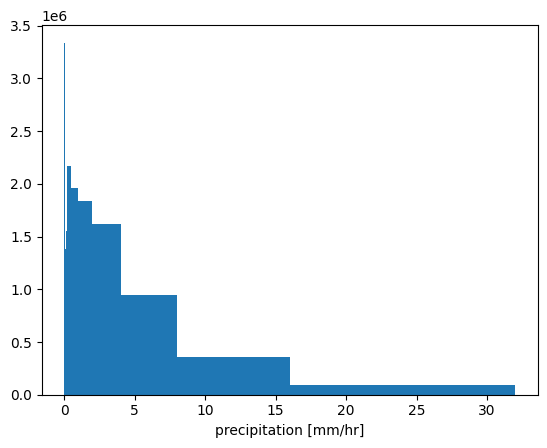

In [28]:
ew4_imerge_sample_ds['precipitation'].plot.hist(bins=precip_plot_bins)


We can also plot the data using matplotlib to check we have data that matches our expectation

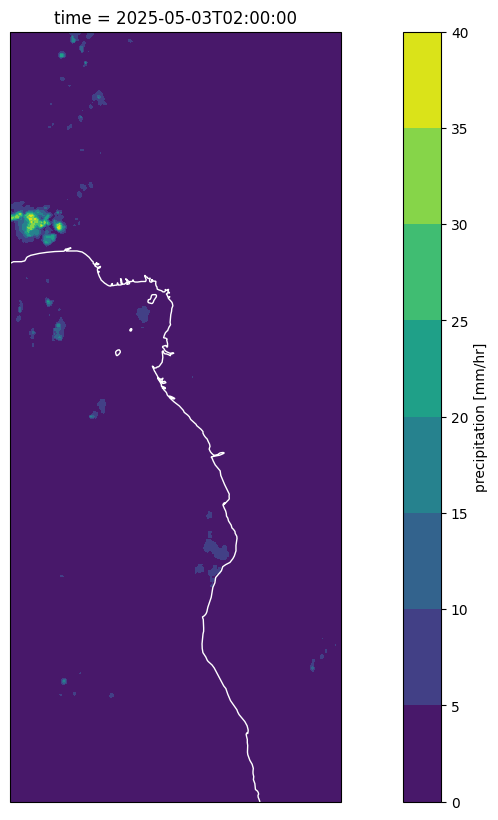

In [29]:
fig1 = matplotlib.pyplot.figure(figsize=(16,10))
ax1=fig1.add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())
ew4_imerge_sample_ds['precipitation'][100].plot.contourf(ax=ax1)
ax1.coastlines(color='w')

## Loading the Data in PyEarthTools
Now we will load the data through the PyEarthTools data accessor. This is a class that has been created which how to access the data. For a dataset like this which is stored as files on disk, it specifries which files to load. Data could be loaded through other mechanisms though, for example it could be load from a database, through a web api, from a tape archive,  from a cloud-based object store or many other mechanisms.

We will take a look at the construction of the accessor, which can be found here:
* [IMERG Data Accessor](https://github.com/MetOffice/pyearthtools_jasmin/blob/main/src/site_archive_jasmin/ew4_imerg.py)
* [Template for Data Accessors](https://github.com/MetOffice/pyearthtools_jasmin/blob/main/src/site_archive_jasmin/template_accessor.py)

Further Reading 
* [
* [PyEarthTools and Data Access](https://pyearthtools.readthedocs.io/en/latest/data.html)
* [Data Module Deep Dive Tutorials](https://pyearthtools.readthedocs.io/en/latest/notebooks/Gallery.html#Deep-Dive---The-Data-Module)


In [30]:
ew4_imerg_accessor = petdata.archive.ew4_imerg_2025('2025-04-01 00:00', '2025-10-01 00:00')

In [31]:
ew4_imerg_accessor

Ew4Imerg
	Description                    GPM IMERG - EW4Energy project 
		 range                          '2025-04-01 to 2025-09-30'
		 Documentation                  'https://gpm.nasa.gov/data/imerg'


	Initialisation                 
		 end                            '2025-10-01 00:00'
		 start                          '2025-04-01 00:00'
	Transforms                     
		 StandardCoordinateNames        {'latitude': "['lat', 'Latitude', 'yt_ocean', 'yt']", 'longitude': "['lon', 'Longitude', 'xt_ocean', 'xt']", 'replacement_dictionary': 'None', 'time': "['Time']"}

In [32]:
ew4_imerg_accessor['2025-05-23 03:00']

/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(


<xarray.Dataset> Size: 382kB
Dimensions:        (time: 1, longitude: 469, latitude: 202)
Coordinates:
  * time           (time) datetime64[ns] 8B 2025-05-23T03:00:00
  * longitude      (longitude) float32 2kB -27.05 -26.95 -26.85 ... 19.65 19.75
  * latitude       (latitude) float32 808B 0.05 0.15 0.25 ... 19.95 20.05 20.15
Data variables:
    precipitation  (time, longitude, latitude) float32 379kB dask.array<chunksize=(1, 469, 202), meta=np.ndarray>
Attributes:
    CDI:                                    Climate Data Interface version 1....
    Conventions:                            CF-1.6
    Original_Producer_Metadata_FileHeader:  DOI=10.5067/GPM/IMERG/3B-HH-E/07;...
    Original_Producer_Metadata_FileInfo:    DataFormatVersion=7e;\nTKCodeBuil...
    Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegis...
    InputPointer:                           3B-HHR-E.MS.MRG.3IMERG.20250523-S...
    history_L34RS:                          'Created by L34RS v1.4.4 @ NASA G...
    CDO:                                    Climate Data Operators version 1....

In [33]:
ew4_imerg_accessor['2025-05-23']



<xarray.Dataset> Size: 9MB
Dimensions:        (time: 24, longitude: 469, latitude: 202)
Coordinates:
  * time           (time) datetime64[ns] 192B 2025-05-23 ... 2025-05-23T23:00:00
  * longitude      (longitude) float32 2kB -27.05 -26.95 -26.85 ... 19.65 19.75
  * latitude       (latitude) float32 808B 0.05 0.15 0.25 ... 19.95 20.05 20.15
Data variables:
    precipitation  (time, longitude, latitude) float32 9MB dask.array<chunksize=(1, 469, 202), meta=np.ndarray>
Attributes:
    CDI:                                    Climate Data Interface version 1....
    Conventions:                            CF-1.6
    Original_Producer_Metadata_FileInfo:    DataFormatVersion=7e;\nTKCodeBuil...
    Original_Producer_Metadata_GridHeader:  BinMethod=ARITHMETIC_MEAN;\nRegis...
    CDO:                                    Climate Data Operators version 1....

/home/users/shaddad/prog/pet_fork/packages/data/src/pyearthtools/data/indexes/_indexes.py:779: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(


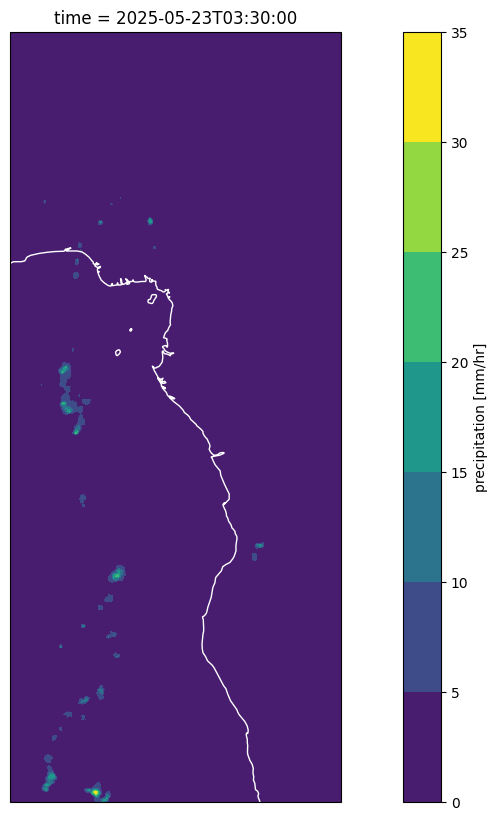

In [34]:
fig1 = matplotlib.pyplot.figure(figsize=(16,10))
ax1=fig1.add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())
ew4_imerg_accessor['2025-05-23 03:30']['precipitation'][0].plot.contourf(ax=ax1)

ax1.coastlines(color='w')


To demonstrate working with just a region of interest, we will select some data roughly corresponding to Ghana. The bounds have been tweaked a little so we can an array of a power of 2 size (64x64) as this is conveneient for working with a convolutional neural network.

## Building a pipeline
Generally we are loading the data with pyEarthTools to prepare for use with a machine learning algorithm, either for training or inference. Once the data is loaded, there are other processing steps thatw we will need to do to prepare the data. This includes:
* selecting a geopgraphical region of interest
* train/validate/test split
* normalising data

With PyEarthTools, these steps are done by *pipeline operations* and *data transforms*
 

In [13]:
ghana_extents = {
    'latitude': (4.7,11.1),
    'longitude': (-3.5, 2.9),
}


In [14]:
ghana_pet_box = (ghana_extents['latitude'][0],
                 ghana_extents['latitude'][1],
                 ghana_extents['longitude'][0],
                 ghana_extents['longitude'][1],
                )

We will also add a cache step, to 

In [104]:
ew4_imerg_prep = petpipe.Pipeline(
    ew4_imerg_accessor,
    petdata.transform.region.Bounding(*ghana_pet_box),
    pyearthtools.pipeline.modifications.Cache(
        ew4_imerg_cache_dir,
        pattern_kwargs={'extension': 'nc'},
        cache_validity='override',
    ),
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError,
)


In [101]:
ew4_imerg_norm_segment = petpipe.Pipeline(
    pyearthtools.pipeline.operations.xarray.normalisation.MagicNorm(cache_dir=imerg_norm_dir),
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError,
)


The last part is to convert to numpy arrays and cache those, so we can load the data as quickly as possible for training with pytorch.

In [105]:
ew4_imerg_ml = petpipe.Pipeline(
    petpipe.operations.xarray.conversion.ToNumpy(),
    petpipe.operations.numpy.reshape.Rearrange('c t h w -> t c h w'), # channel time height width -> time channel height width
    pyearthtools.pipeline.modifications.Cache( ew4_imerg_ml_prepped_dir,
                                               pattern_kwargs={'extension': 'npy'},
                                             ),
    iterator=petpipe.iterators.DateRange('20250501T00', '20250701T00', interval='1 hour'), 
)

We now iterate through the data to calculate norms and populate the cache.

In [106]:
ew4_imerg_pipe = ew4_imerg_prep | ew4_imerg_norm_segment | ew4_imerg_ml

In [107]:
sample = [sample1 for sample1 in ew4_imerg_pipe]

We can now use the mean and standard deviation calculated here to normalise the data in our training pipeline

We can see in the following cells what iterating on our pipeline is actually giving us.

In [109]:
test_it = iter(ew4_imerg_pipe)
test_list = [next(test_it), next(test_it), next(test_it)]

In [111]:
test_it

<generator object Pipeline.__iter__ at 0x7f1169e963e0>

In [110]:
test_list

[array([[[[-0.14259997, -0.14259997, -0.14259997, ..., -0.14259997,
           -0.14259997, -0.14259997],
          [-0.14259997, -0.14259997, -0.14259997, ..., -0.14259997,
           -0.14259997, -0.14259997],
          [-0.14259997, -0.14259997, -0.14259997, ..., -0.14259997,
           -0.14259997, -0.14259997],
          ...,
          [-0.14259997, -0.14259997, -0.14259997, ...,  0.00926937,
            0.16113871,  0.41425428],
          [-0.14259997, -0.14259997, -0.14259997, ...,  0.16113871,
            0.18645024,  0.21176182],
          [-0.14259997, -0.14259997, -0.14259997, ...,  0.21176182,
            0.23707335,  0.313008  ]]]],
       shape=(1, 1, 64, 64), dtype=float32),
 array([[[[-0.20931712, -0.20931712, -0.20931712, ..., -0.20931712,
           -0.20931712, -0.20931712],
          [-0.20931712, -0.20931712, -0.20931712, ..., -0.20931712,
           -0.20931712, -0.20931712],
          [-0.20931712, -0.20931712, -0.20931712, ..., -0.20931712,
           -0.2093171

Pipeline are modular, so we can still use the prep part of the pipeline on its own, if for example we wanted the original xarray data to plot

In [112]:
imerg_sampler_pipe = petpipe.Pipeline(
    ew4_imerg_prep,
    iterator=petpipe.iterators.DateRange('20250501T00', '20250701T00', interval='1 hour'), 
)
sample_it = iter(imerg_sampler_pipe)

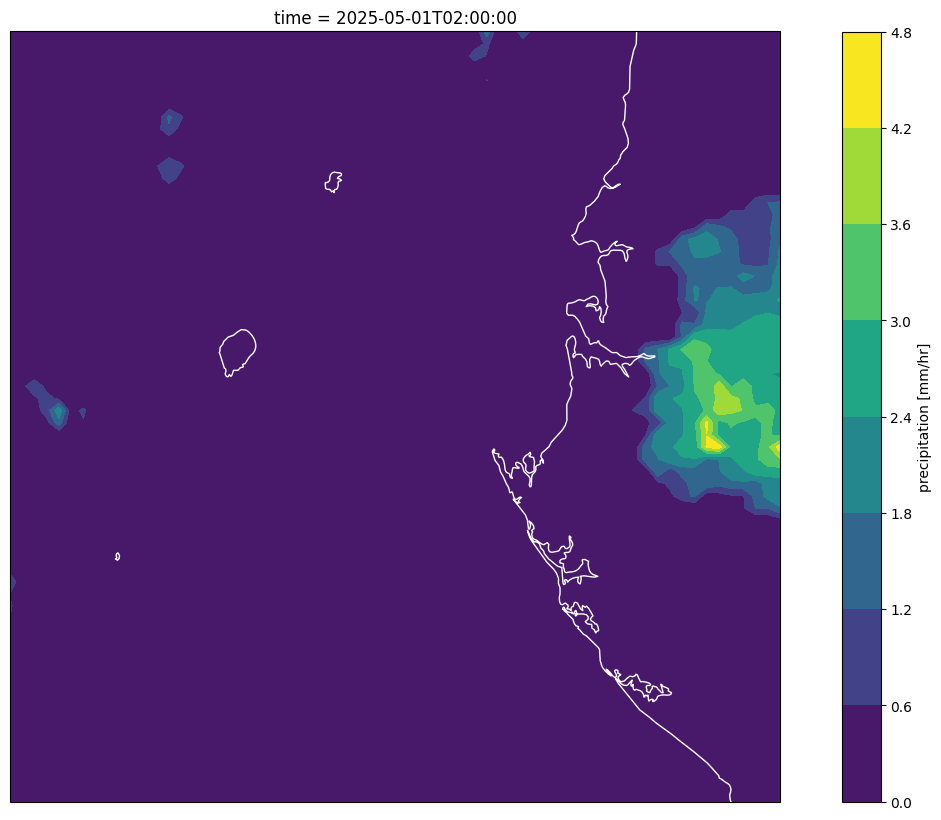

In [115]:
fig1 = matplotlib.pyplot.figure(figsize=(16,10))
ax1=fig1.add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())
next(sample_it)['precipitation'][0].plot.contourf(ax=ax1)
ax1.coastlines(color='w')


## Further Links

* [PyEarthTools Docs](https://pyearthtools.readthedocs.io/en/latest/)
  * [Tutorial Gallery](https://pyearthtools.readthedocs.io/en/latest/notebooks/Gallery.html)
* [PyEarthTools Repo](https://github.com/ACCESS-Community-Hub/PyEarthTools)
* [PyEarthTools JASMIN Site Archive Repo](https://github.com/MetOffice/pyearthtools_jasmin/)
*  [IMERG Dataset Info](https://gpm.nasa.gov/data/imerg)